In [438]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import random
from src.data.data import get_ds

In [439]:
class_to_index={"standing":0, "running":1, "walking":2,"badminton":3}

train_ds, test_ds = get_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/basicmotions/BasicMotions_TRAIN.ts", class_to_index), get_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/basicmotions/BasicMotions_TEST.ts", class_to_index)
len(train_ds)

40

In [440]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout

        self.lstm = nn.LSTM(self.input_size, self.hidden_size, self.num_layers, dropout=self.dropout)


    def forward(self, x):
        """
        x: (seq_len, batch_size, input_size=1)
        """
        _, (hidden, cell) = self.lstm(x)
        # hidden: (num_layers, batch_size, hidden_size)
        # cell: (num_layers. batch_size, hidden_size)
        return hidden, cell
    
class Decoder(nn.Module):
    def __init__(self, output_size, hidden_size, num_layers, dropout):
        super().__init__()

        self.output_size = output_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout

        self.lstm = nn.LSTM(self.output_size, self.hidden_size, self.num_layers, dropout=self.dropout)
        self.fc = nn.Linear(self.hidden_size, self.output_size)

    def forward(self, x, hidden, cell):
        """
        x: (batch_size)
        hidden: (num_layers, batch_size, hidden_size)
        cell: (num_layers, batch_size, hidden_size)
        """
        x = x.unsqueeze(0)
        # x = (1, batch_size, 1)
        output, (hidden, cell) = self.lstm(x, (hidden, cell))
        # output: (1, batch_size, hidden_size)
        # hidden: (num_layers, batch_size, hidden_size)
        # cell: (num_layers, batch_size, hidden_size)
        prediction = self.fc(output)
        # prediction: (batch_size, output_size=1)
        return prediction, hidden, cell

In [441]:
class Autoencoder(nn.Module):
    def __init__(self, seq_len, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        
        self.seq_len = seq_len

        self.encoder = Encoder(input_size, hidden_size, num_layers, dropout)
        self.decoder = Decoder(input_size, hidden_size, num_layers, dropout)

    def forward(self, x):
        """
        x: (seq_len, batch_size)
        """
        batch_size = x.shape[1]

        # outputs: (seq_len, batch_size, input_size=1)
        outputs = torch.zeros(self.seq_len, batch_size, self.decoder.output_size)

        hidden, cell = self.encoder(x)
        # hidden: (num_layers, batch_size, hidden_size)
        # cell: (num_layers. batch_size, hidden_size)

        input = x[0, :]
        # input: (1, batch_size)
        for t in range(1, self.seq_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            # output = (batch_size, output_size=1)
            # hidden: (num_layers, batch_size, hidden_size)
            # cell: (num_layers, batch_size, hidden_size)
            outputs[t] = output

            input = x[t]
        return outputs



In [442]:
autoencoder = Autoencoder(100, 1, 20, 2, 0)

def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param.data, -0.08, 0.08)
        
autoencoder.apply(init_weights)

Autoencoder(
  (encoder): Encoder(
    (lstm): LSTM(1, 20, num_layers=2)
  )
  (decoder): Decoder(
    (lstm): LSTM(1, 20, num_layers=2)
    (fc): Linear(in_features=20, out_features=1, bias=True)
  )
)

In [443]:
epochs = 500
opt = torch.optim.Adam(autoencoder.parameters(), lr=0.01)
sched = torch.optim.lr_scheduler.ExponentialLR(opt, 0.999)
criterion = nn.MSELoss()

In [444]:
data_load = torch.utils.data.DataLoader(train_ds, len(train_ds), False)
autoencoder.train()
for epoch in range(epochs):
    for data_matrix, labels in data_load:
        accel_x = data_matrix[:, :, 0].transpose(0, 1).unsqueeze(2).float()
        
        output = autoencoder(accel_x)

        loss = criterion(accel_x, output)
        opt.zero_grad()
        loss.backward()
        opt.step()

    sched.step()
    print("Epoch: ", epoch, " Loss: ", float(loss))



Epoch:  0  Loss:  56.95286560058594
Epoch:  1  Loss:  56.77892303466797
Epoch:  2  Loss:  56.57467269897461
Epoch:  3  Loss:  56.27174758911133
Epoch:  4  Loss:  55.76885223388672
Epoch:  5  Loss:  54.912410736083984
Epoch:  6  Loss:  53.69429016113281
Epoch:  7  Loss:  52.51201248168945
Epoch:  8  Loss:  51.636497497558594
Epoch:  9  Loss:  50.98392105102539
Epoch:  10  Loss:  50.47367858886719
Epoch:  11  Loss:  50.08707809448242
Epoch:  12  Loss:  49.82623291015625
Epoch:  13  Loss:  49.682289123535156
Epoch:  14  Loss:  49.63019943237305
Epoch:  15  Loss:  49.63082504272461
Epoch:  16  Loss:  49.6379280090332
Epoch:  17  Loss:  49.60857009887695
Epoch:  18  Loss:  49.51080322265625
Epoch:  19  Loss:  49.32718276977539
Epoch:  20  Loss:  49.05624771118164
Epoch:  21  Loss:  48.70552444458008
Epoch:  22  Loss:  48.280364990234375
Epoch:  23  Loss:  47.784698486328125
Epoch:  24  Loss:  47.23663330078125
Epoch:  25  Loss:  46.66490173339844
Epoch:  26  Loss:  46.092369079589844
Epoch:

Blue = original, Red = reconstructed


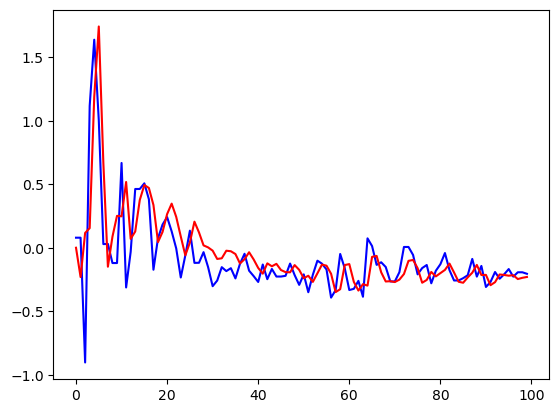

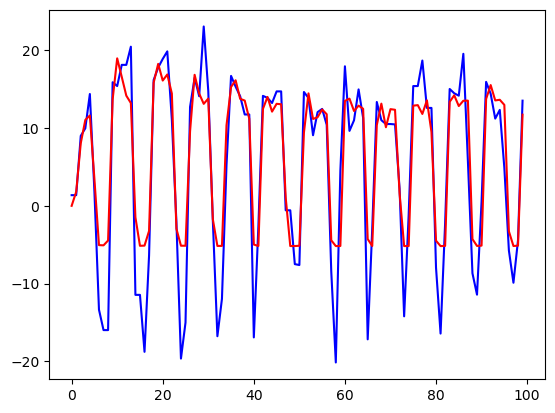

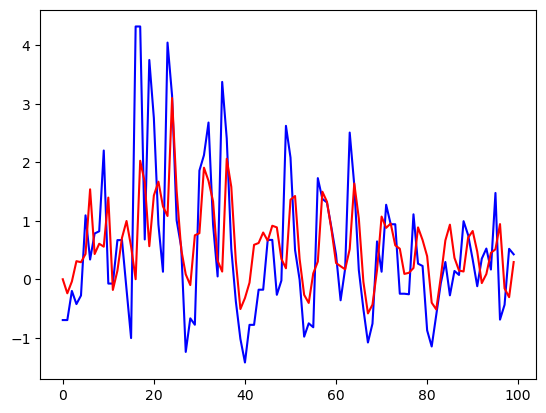

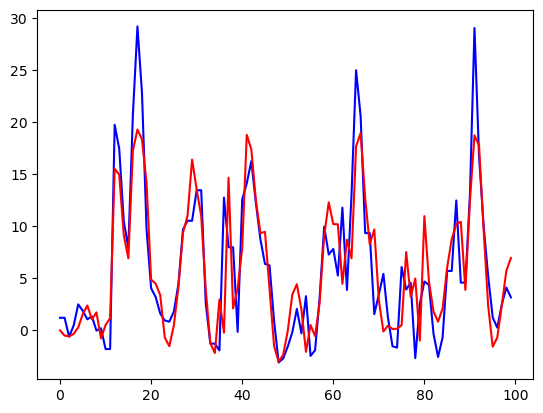

In [446]:
data_load = torch.utils.data.DataLoader(train_ds, len(train_ds), False)
for data_matrix, labels in data_load:
    accel_x = data_matrix[:, :, 0].transpose(0, 1).unsqueeze(2).float()
    with torch.no_grad():
        output = autoencoder(accel_x)
        print("Blue = original, Red = reconstructed")
        plt.figure()
        index = random.randint(0, 9)
        p1 = accel_x[:, index, :].squeeze()
        p2 = output[:, index, :]

        plt.plot(p1, c='b')
        plt.plot(p2, c='r')

        plt.figure()
        index = random.randint(10, 19)
        p1 = accel_x[:, index, :].squeeze()
        p2 = output[:, index, :]

        plt.plot(p1, c='b')
        plt.plot(p2, c='r')

        plt.figure()
        index = random.randint(20, 29)
        p1 = accel_x[:, index, :].squeeze()
        p2 = output[:, index, :]

        plt.plot(p1, c='b')
        plt.plot(p2, c='r')

        plt.figure()
        index = random.randint(30, 39)
        p1 = accel_x[:, index, :].squeeze()
        p2 = output[:, index, :]

        plt.plot(p1, c='b')
        plt.plot(p2, c='r')

        plt.show()




Blue = original, Red = reconstructed


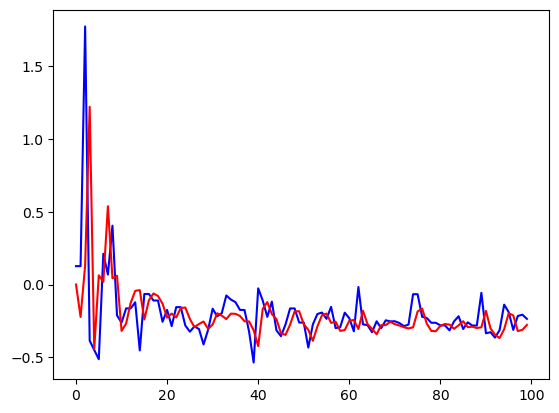

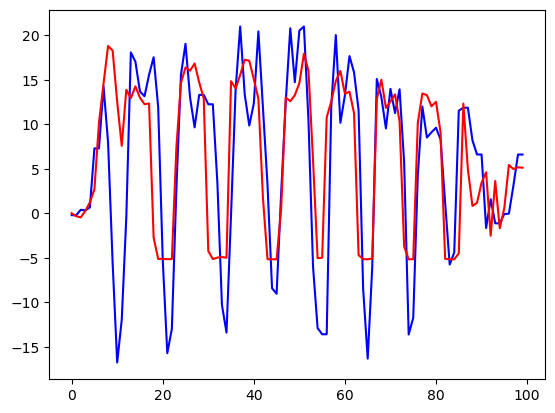

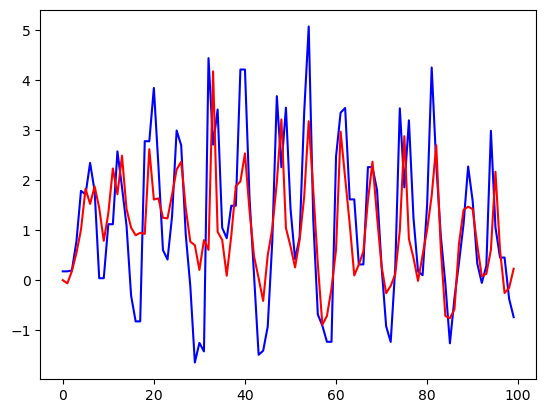

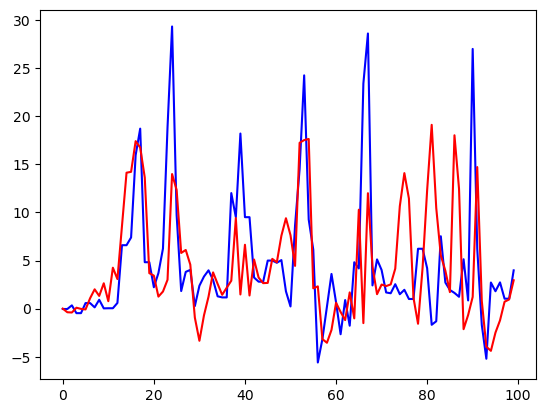

In [450]:
data_load = torch.utils.data.DataLoader(test_ds, len(test_ds), False)
for data_matrix, labels in data_load:
    accel_x = data_matrix[:, :, 0].transpose(0, 1).unsqueeze(2).float()
    with torch.no_grad():
        output = autoencoder(accel_x)
        print("Blue = original, Red = reconstructed")
        plt.figure()
        index = random.randint(0, 9)
        p1 = accel_x[:, index, :].squeeze()
        p2 = output[:, index, :]

        plt.plot(p1, c='b')
        plt.plot(p2, c='r')

        plt.figure()
        index = random.randint(10, 19)
        p1 = accel_x[:, index, :].squeeze()
        p2 = output[:, index, :]

        plt.plot(p1, c='b')
        plt.plot(p2, c='r')

        plt.figure()
        index = random.randint(20, 29)
        p1 = accel_x[:, index, :].squeeze()
        p2 = output[:, index, :]

        plt.plot(p1, c='b')
        plt.plot(p2, c='r')

        plt.figure()
        index = random.randint(30, 39)
        p1 = accel_x[:, index, :].squeeze()
        p2 = output[:, index, :]

        plt.plot(p1, c='b')
        plt.plot(p2, c='r')

        plt.show()


